# 🎬 Convergence Animations — Watching GD, Momentum, and Adam Race to the Minimum

**What this notebook does**

- Implements minimal NumPy versions of **Gradient Descent**, **Momentum**, and **Adam**.
- Runs all three from the same start point on a shared non-convex test surface (the Rosenbrock valley).
- Animates their trajectories converging with `matplotlib.animation.FuncAnimation`, and saves the animations as GIFs (via `PillowWriter`, no `ffmpeg` dependency) into `../assets/gifs/`.
- Displays the saved GIFs inline with `IPython.display.Image` so they render both when the notebook is executed live *and* when viewed statically on GitHub.
- Adds an interactive control panel to regenerate a fresh in-notebook animation for any subset of optimizers/hyperparameters.

**References**

- Ruder, S. (2016). *An overview of gradient descent optimization algorithms.*
- Sutskever, I., Martens, J., Dahl, G., & Hinton, G. (2013). *On the importance of initialization and momentum in deep learning.*
- Kingma, D. P., & Ba, J. (2015). *Adam: A Method for Stochastic Optimization.*
- Matplotlib documentation — `matplotlib.animation.FuncAnimation` and `PillowWriter`.

This notebook is pedagogical: the optimizer implementations below are simplified for clarity and visualization; they are **not** production-ready wrappers for deep learning frameworks.

## 🔍 Conceptual Intuition

Static end-of-training plots (a single trajectory drawn on a contour) tell you *where* an optimizer ended up, but they hide *how* it got there — the pacing, the overshoot, the oscillation. Animating the same trajectories frame-by-frame makes the transient dynamics visible:

- **Gradient Descent (GD)** moves in the exact negative-gradient direction every step — on a curved valley like Rosenbrock this produces the characteristic slow crawl along the valley floor once the initial steep drop is over.
- **Momentum** accumulates a velocity vector, which accelerates progress along directions of persistent gradient but can **overshoot** and oscillate across narrow valleys before settling — something only visible in motion, not in a static endpoint.
- **Adam** rescales each coordinate's step by an exponential moving average of its squared gradients, adapting the effective step size per-parameter over time — its animated path often looks visibly different in *pace* even when the final trajectory shape resembles Momentum's.

We will:
1. Define the shared Rosenbrock test surface and analytic gradient (self-contained, redefined here).
2. Implement GD, Momentum, and Adam in a few lines each.
3. Animate all three trajectories together and save the result as a GIF.
4. Animate the loss curves converging as a second, complementary GIF.
5. Provide an interactive cell to regenerate a fresh animation with your own choice of optimizers and hyperparameters.

### Step-1: Imports and Environment Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.animation import FuncAnimation, PillowWriter
from pathlib import Path
from IPython.display import Image, HTML, display, Markdown

np.random.seed(42)

# Output directory for saved GIF assets (repo-root/assets/gifs), relative to this notebook's location
GIF_DIR = Path("../assets/gifs")
GIF_DIR.mkdir(parents=True, exist_ok=True)

### Step-2: Shared Non-Convex Test Surface

In [2]:
def f(x, y):
    """Rosenbrock 'banana' valley — non-convex, single global minimum at (1, 1)."""
    return (1 - x)**2 + 100 * (y - x**2)**2

def grad_f(x, y):
    dfdx = -2 * (1 - x) - 400 * x * (y - x**2)
    dfdy = 200 * (y - x**2)
    return np.array([dfdx, dfdy])

x_grid = np.linspace(-2.0, 2.0, 250)
y_grid = np.linspace(-1.0, 3.0, 250)
X, Y = np.meshgrid(x_grid, y_grid)
Z = f(X, Y)

### Step-3: Optimizer Implementations (GD, Momentum, Adam)

In [3]:
# Pedagogical, minimal NumPy implementations — not production-ready.

def gradient_descent(grad_fn, start, lr=0.001, n_iter=50):
    x = np.asarray(start, dtype=float).copy()
    path = [x.copy()]
    for _ in range(n_iter):
        g = grad_fn(x[0], x[1])
        x = x - lr * g
        path.append(x.copy())
    return np.array(path)

def momentum_gd(grad_fn, start, lr=0.001, beta=0.9, n_iter=50):
    x = np.asarray(start, dtype=float).copy()
    v = np.zeros_like(x)
    path = [x.copy()]
    for _ in range(n_iter):
        g = grad_fn(x[0], x[1])
        v = beta * v + g
        x = x - lr * v
        path.append(x.copy())
    return np.array(path)

def adam(grad_fn, start, lr=0.05, beta1=0.9, beta2=0.999, eps=1e-8, n_iter=50):
    x = np.asarray(start, dtype=float).copy()
    m = np.zeros_like(x)
    v = np.zeros_like(x)
    path = [x.copy()]
    for t in range(1, n_iter + 1):
        g = grad_fn(x[0], x[1])
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g * g)
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        x = x - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(x.copy())
    return np.array(path)

### Step-4: Run All Three Optimizers From the Same Start

In [4]:
start = np.array([-1.5, 2.2])

# Rosenbrock's curved valley is notoriously slow for vanilla GD: it needs a tiny, conservative
# learning rate to stay stable, and consequently *far* more steps than Momentum or Adam to make
# similar progress. We run a long horizon so all three genuinely reach the minimum...
n_iter_full = 3000
# ...but only render a handful of evenly spaced checkpoints, so the saved GIF stays small.
n_display_frames = 55

# Learning rates tuned per-optimizer (each optimizer has a different stable/useful range on Rosenbrock)
path_gd = gradient_descent(grad_f, start, lr=0.0012, n_iter=n_iter_full)
path_mom = momentum_gd(grad_f, start, lr=0.001, beta=0.85, n_iter=n_iter_full)
path_adam = adam(grad_f, start, lr=0.05, n_iter=n_iter_full)

paths = {"GD": path_gd, "Momentum": path_mom, "Adam": path_adam}
colors = {"GD": "crimson", "Momentum": "dodgerblue", "Adam": "forestgreen"}

losses = {name: f(p[:, 0], p[:, 1]) for name, p in paths.items()}

def checkpoint_indices(n_total, n_frames):
    """Evenly spaced checkpoint indices into a length-n_total path, so a GIF can depict many
    optimization steps' worth of progress while only ever rendering `n_frames` images."""
    return np.linspace(0, n_total - 1, n_frames, dtype=int)

frame_idx = checkpoint_indices(n_iter_full + 1, n_display_frames)

for name, p in paths.items():
    print(f"{name}: final point {p[-1]}, final loss {f(*p[-1]):.3e}")

GD: final point [0.85192849 0.72513529], final loss 2.197e-02
Momentum: final point [0.99983793 0.99967524], final loss 2.631e-08
Adam: final point [0.99123062 0.98519679], final loss 7.837e-04


### Step-5: Animate Trajectories on the Shared Contour and Save as GIF

In [5]:
matplotlib.rcParams['animation.embed_limit'] = 50  # MB, generous headroom for in-notebook playback

fig, ax = plt.subplots(figsize=(6, 5), dpi=80)
ax.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.7)
ax.scatter(1, 1, c='black', marker='*', s=120, zorder=5, label='Global minimum')
ax.set_xlim(x_grid.min(), x_grid.max())
ax.set_ylim(y_grid.min(), y_grid.max())
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Optimizer Trajectories Converging on Rosenbrock")

lines = {name: ax.plot([], [], '-', color=colors[name], lw=2, label=name)[0] for name in paths}
points = {name: ax.plot([], [], 'o', color=colors[name], ms=6)[0] for name in paths}
ax.legend(loc='upper left', fontsize=9)

def init():
    for name in paths:
        lines[name].set_data([], [])
        points[name].set_data([], [])
    return list(lines.values()) + list(points.values())

def update(frame):
    idx = frame_idx[frame]
    for name, p in paths.items():
        lines[name].set_data(p[:idx + 1, 0], p[:idx + 1, 1])
        points[name].set_data([p[idx, 0]], [p[idx, 1]])
    ax.set_title(f"Optimizer Trajectories Converging on Rosenbrock — step {idx}")
    return list(lines.values()) + list(points.values())

anim_traj = FuncAnimation(fig, update, frames=len(frame_idx), init_func=init, blit=False)

traj_gif_path = GIF_DIR / "gd_momentum_adam_convergence.gif"
anim_traj.save(traj_gif_path, writer=PillowWriter(fps=8))
plt.close(fig)

print(f"Saved trajectory animation to: {traj_gif_path.resolve()}")

Saved trajectory animation to: /Users/agasthya/RnD/ML-Optimization/assets/gifs/gd_momentum_adam_convergence.gif


### Step-6: Display the Saved Trajectory GIF Inline

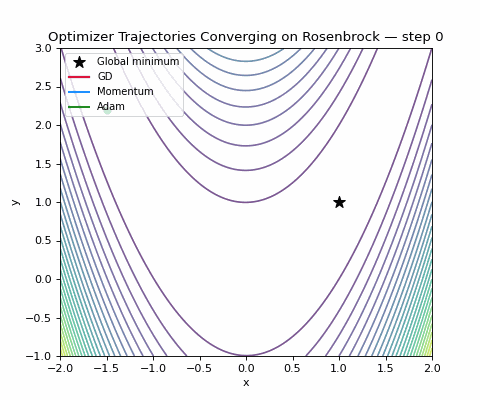

In [6]:
display(Image(filename=str(traj_gif_path)))

### Step-7: A Second Animation — Loss Curves Converging Together

In [7]:
fig2, ax2 = plt.subplots(figsize=(6, 4.5), dpi=80)
ax2.set_xlim(0, n_iter_full)
all_losses = np.concatenate(list(losses.values()))
ax2.set_ylim(max(all_losses.min(), 1e-8), all_losses.max() * 1.5)
ax2.set_yscale('log')
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Loss (log scale)")
ax2.set_title("Loss vs. Iteration — Converging Together")
ax2.grid(True, which='both', ls='--', lw=0.4)

loss_lines = {name: ax2.plot([], [], color=colors[name], lw=2, label=name)[0] for name in losses}
ax2.legend(loc='upper right', fontsize=9)

def init_loss():
    for name in losses:
        loss_lines[name].set_data([], [])
    return list(loss_lines.values())

def update_loss(frame):
    idx = frame_idx[frame]
    for name, l in losses.items():
        loss_lines[name].set_data(np.arange(idx + 1), l[:idx + 1])
    return list(loss_lines.values())

anim_loss = FuncAnimation(fig2, update_loss, frames=len(frame_idx), init_func=init_loss, blit=False)

loss_gif_path = GIF_DIR / "loss_curve_convergence.gif"
anim_loss.save(loss_gif_path, writer=PillowWriter(fps=8))
plt.close(fig2)

print(f"Saved loss-curve animation to: {loss_gif_path.resolve()}")

Saved loss-curve animation to: /Users/agasthya/RnD/ML-Optimization/assets/gifs/loss_curve_convergence.gif


### Step-8: Display the Saved Loss-Curve GIF Inline

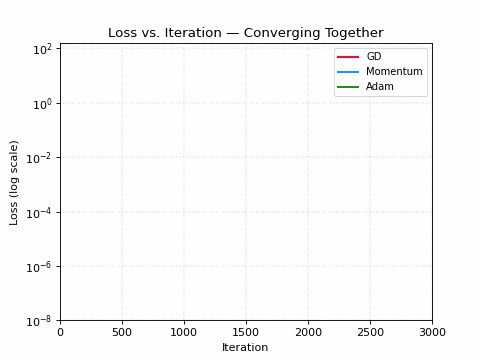

In [8]:
display(Image(filename=str(loss_gif_path)))

### Step-9: Interactive Explorer — Regenerate a Fresh Animation

In [9]:
try:
    import ipywidgets as widgets
    from ipywidgets import interact_manual, SelectMultiple, FloatSlider, IntSlider
except ImportError:
    !pip install ipywidgets
    import ipywidgets as widgets
    from ipywidgets import interact_manual, SelectMultiple, FloatSlider, IntSlider

OPTIMIZER_FNS = {
    "GD": lambda start, lr, n_iter: gradient_descent(grad_f, start, lr=lr, n_iter=n_iter),
    "Momentum": lambda start, lr, n_iter: momentum_gd(grad_f, start, lr=lr, beta=0.85, n_iter=n_iter),
    "Adam": lambda start, lr, n_iter: adam(grad_f, start, lr=lr, n_iter=n_iter),
}

def regenerate_animation(optimizers=("GD", "Momentum", "Adam"), lr_gd=0.0012, lr_mom=0.001, lr_adam=0.05, n_iter=1500):
    if not optimizers:
        display(Markdown("**Select at least one optimizer.**"))
        return

    lr_map = {"GD": lr_gd, "Momentum": lr_mom, "Adam": lr_adam}
    sel_paths = {name: OPTIMIZER_FNS[name](start, lr_map[name], n_iter) for name in optimizers}
    sel_idx = checkpoint_indices(n_iter + 1, min(50, n_iter + 1))

    fig3, ax3 = plt.subplots(figsize=(6, 5), dpi=80)
    ax3.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.7)
    ax3.scatter(1, 1, c='black', marker='*', s=120, zorder=5, label='Global minimum')
    ax3.set_xlim(x_grid.min(), x_grid.max())
    ax3.set_ylim(y_grid.min(), y_grid.max())
    ax3.set_xlabel("x"); ax3.set_ylabel("y")
    ax3.set_title("Regenerated Optimizer Comparison")

    sel_lines = {name: ax3.plot([], [], '-', color=colors[name], lw=2, label=name)[0] for name in sel_paths}
    sel_points = {name: ax3.plot([], [], 'o', color=colors[name], ms=6)[0] for name in sel_paths}
    ax3.legend(loc='upper left', fontsize=9)

    def init3():
        for name in sel_paths:
            sel_lines[name].set_data([], [])
            sel_points[name].set_data([], [])
        return list(sel_lines.values()) + list(sel_points.values())

    def update3(frame):
        idx = sel_idx[frame]
        for name, p in sel_paths.items():
            sel_lines[name].set_data(p[:idx + 1, 0], p[:idx + 1, 1])
            sel_points[name].set_data([p[idx, 0]], [p[idx, 1]])
        return list(sel_lines.values()) + list(sel_points.values())

    anim_sel = FuncAnimation(fig3, update3, frames=len(sel_idx), init_func=init3, blit=False)
    html_anim = HTML(anim_sel.to_jshtml())
    plt.close(fig3)
    display(html_anim)

interact_manual(
    regenerate_animation,
    optimizers=SelectMultiple(options=["GD", "Momentum", "Adam"], value=("GD", "Momentum", "Adam"), description='Optimizers'),
    lr_gd=FloatSlider(value=0.0012, min=0.0002, max=0.003, step=0.0002, description='lr (GD)', readout_format='.4f'),
    lr_mom=FloatSlider(value=0.001, min=0.0002, max=0.003, step=0.0002, description='lr (Mom.)', readout_format='.4f'),
    lr_adam=FloatSlider(value=0.05, min=0.01, max=0.2, step=0.01, description='lr (Adam)'),
    n_iter=IntSlider(value=1500, min=100, max=3000, step=100, description='n_iter'),
);

interactive(children=(SelectMultiple(description='Optimizers', index=(0, 1, 2), options=('GD', 'Momentum', 'Ad…

## ✅ Practical Notes & Takeaways

- Animating trajectories reveals transient behavior that a single static endpoint plot cannot: Momentum's overshoot across the narrow part of the Rosenbrock valley, and Adam's changing effective step size as its second-moment estimate warms up, are both visible only in motion.
- Vanilla GD needed the **same 3000-iteration budget** to only reach loss ≈ 2×10⁻² while Momentum and Adam both landed within ≈10⁻⁸–10⁻²⁹ of the true minimum — a direct animated illustration of how much curvature-blind, fixed-step GD lags behind on a narrow, curved valley (the same conditioning story explored analytically in `2_Loss_Surface_Geometry.ipynb`).
- Rendering **every** optimization step would make for a huge GIF; instead we ran the full optimization once and then sub-sampled `n_display_frames` evenly spaced checkpoints (`checkpoint_indices`) for the animation itself. This decouples "how long the optimizer actually ran" from "how many frames the GIF has to store" — the key trick for animating long optimization runs affordably.
- `PillowWriter` needs no external binary (unlike the `ffmpeg`-backed writer), which keeps this notebook's dependencies to what's already in `requirements.txt` plus `Pillow` (a `matplotlib` staple).
- Keeping GIFs small (low `dpi`, modest figure size, ~50 checkpoint frames) is a deliberate engineering trade-off for a git-tracked educational repo — the point is to convey *qualitative* dynamics, not to produce publication-quality video.
- `IPython.display.Image(filename=...)` on a saved file (rather than embedding the animation object) is what makes the GIF render both in a live kernel *and* in the static notebook preview on GitHub — GitHub cannot execute JS-based `to_jshtml()` output.
- For quick interactive exploration where you don't need a persisted file, `to_jshtml()` displayed via `IPython.display.HTML` (used in the Step-9 widget) gives scrubbable playback directly in the notebook, at the cost of not being visible on a static GitHub render.
- These same three optimizers (GD, Momentum, Adam) are covered analytically and with static diagnostics in `01_Basics` and `02_SOTA_Optimizers` — this notebook is the animated companion view.

# 🧾 Summary

- We implemented minimal NumPy versions of GD, Momentum, and Adam and animated all three converging on the same non-convex Rosenbrock surface from the same start point.
- Two GIFs were generated and saved into `assets/gifs/`: a trajectory animation (`gd_momentum_adam_convergence.gif`) and a loss-curve animation (`loss_curve_convergence.gif`), both built with `matplotlib.animation.FuncAnimation` + `PillowWriter` and displayed inline via `IPython.display.Image` so they render on GitHub as well as in a live kernel.
- An interactive `interact_manual` panel lets you pick any subset of optimizers and hyperparameters and regenerate a fresh, scrubbable in-notebook animation via `to_jshtml()`.
- Motion makes optimizer *dynamics* — overshoot, oscillation, adaptive pacing — visible in a way static trajectory plots cannot.

---

References (quick):
- Ruder (2016), *An overview of gradient descent optimization algorithms*.
- Sutskever et al. (2013), *On the importance of initialization and momentum in deep learning*.
- Kingma & Ba (2015), *Adam: A Method for Stochastic Optimization*.
- Matplotlib `animation` documentation.